In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets

nav = pd.read_csv(
    r"data\processed\02_nav_history_clean.csv"
)

fund_master = pd.read_csv(
    r"data\processed\01_fund_master_clean.csv"
)

transactions = pd.read_csv(
    r"data\processed\08_investor_transactions_clean.csv"
)

holdings = pd.read_csv(
    r"data\raw\09_portfolio_holdings.csv"
)

In [4]:
nav['date'] = pd.to_datetime(nav['date'])
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [5]:
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [6]:
returns = nav.dropna(subset=['daily_return'])

In [7]:
var95 = (
    returns.groupby('amfi_code')['daily_return']
    .quantile(0.05)
    .reset_index()
)

var95.columns = ['amfi_code','VaR_95']

In [8]:
def calculate_cvar(group):

    var = group['daily_return'].quantile(0.05)

    cvar = (
        group[group['daily_return'] <= var]
        ['daily_return']
        .mean()
    )

    return pd.Series({
        'CVaR_95': cvar
    })

In [9]:
cvar95 = (
    returns.groupby('amfi_code')
    .apply(calculate_cvar)
    .reset_index()
)

In [10]:
risk_report = var95.merge(
    cvar95,
    on='amfi_code'
)

risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [11]:
risk_report.to_csv(
    "var_cvar_report.csv",
    index=False
)

In [12]:
top5 = (
    fund_master['amfi_code']
    .drop_duplicates()
    .head(5)
    .tolist()
)

In [13]:
rolling_results = []

for fund in top5:

    temp = returns[
        returns['amfi_code']==fund
    ].copy()

    temp['rolling_sharpe'] = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_results.append(temp)

In [14]:
rolling_sharpe_df = pd.concat(
    rolling_results
)

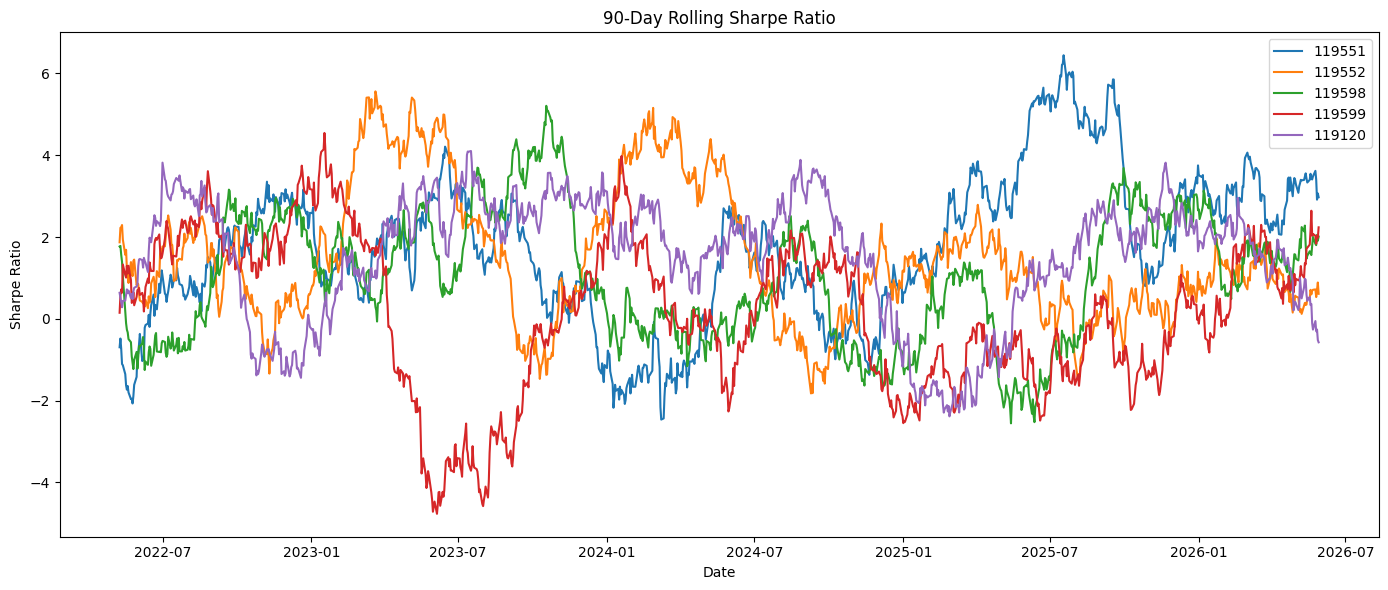

In [15]:
plt.figure(figsize=(14,6))

for fund in top5:

    temp = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code']==fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.legend()
plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "rolling_sharpe_chart.png"
)

plt.show()

In [16]:
first_txn = (
    transactions
    .groupby('investor_id')
    ['transaction_date']
    .min()
    .reset_index()
)

first_txn['cohort_year'] = (
    first_txn['transaction_date']
    .dt.year
)

In [17]:
transactions = transactions.merge(
    first_txn[['investor_id','cohort_year']],
    on='investor_id'
)

In [18]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year']


In [19]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [20]:
cohort_stats = (
    transactions
    .groupby('cohort_year')
    .agg(
        avg_sip_amount=('amount_inr','mean'),
        total_invested=('amount_inr','sum')
    )
    .reset_index()
)

cohort_stats

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [21]:
fund_pref = (
    transactions
    .groupby(['cohort_year','amfi_code'])
    ['amount_inr']
    .sum()
    .reset_index()
)

In [22]:
top_fund = (
    fund_pref
    .sort_values(
        ['cohort_year','amount_inr'],
        ascending=False
    )
    .groupby('cohort_year')
    .first()
    .reset_index()
)

In [23]:
cohort_report = cohort_stats.merge(
    top_fund[['cohort_year','amfi_code']],
    on='cohort_year'
)

cohort_report.head()

,cohort_year,avg_sip_amount,total_invested,amfi_code
0,2024,107422.541832,3491125187,102885
1,2025,109158.577061,30455243,119599


In [24]:
sip = transactions[
    transactions['transaction_type']=="SIP"
].copy()

In [25]:
eligible = (
    sip.groupby('investor_id')
    .size()
)

eligible = eligible[
    eligible>=6
].index

In [26]:
sip = sip[
    sip['investor_id']
    .isin(eligible)
]

In [27]:
sip = sip.sort_values(
    ['investor_id','transaction_date']
)

sip['gap_days'] = (
    sip.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

In [28]:
continuity = (
    sip.groupby('investor_id')
    ['gap_days']
    .mean()
    .reset_index()
)

continuity['status'] = np.where(
    continuity['gap_days'] > 35,
    'At Risk',
    'Healthy'
)

In [29]:
continuity_rate = (
    (continuity['status']=="Healthy")
    .mean()
    *100
)

print(
    f"SIP Continuity Rate: {continuity_rate:.2f}%"
)


SIP Continuity Rate: 2.20%


In [30]:
fund_sharpe = (
    returns.groupby('amfi_code')
    ['daily_return']
    .agg(['mean','std'])
    .reset_index()
)

fund_sharpe['sharpe'] = (
    fund_sharpe['mean']
    /
    fund_sharpe['std']
) * np.sqrt(252)

In [36]:
fund_sharpe['risk_grade'] = pd.qcut(
    fund_sharpe['std'],
    q=3,
    labels=['Low', 'Moderate', 'High']
)

recommend_df = fund_sharpe.merge(
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code'
)

In [37]:
risk = input(
    "Risk Appetite (Low/Moderate/High): "
)

filtered = recommend_df[
    recommend_df['risk_grade']
    == risk
]

result = (
    filtered.sort_values(
        'sharpe',
        ascending=False
    )
    .head(3)
)

print(result[
    ['scheme_name',
     'risk_grade',
     'sharpe']
])

Empty DataFrame
Columns: [scheme_name, risk_grade, sharpe]
Index: []


In [50]:
holdings['weight'] = (
    holdings['weight_percent']
    /100
)

KeyError: 'weight_percent'

In [51]:

# Find weight column automatically
weight_col = None

for col in holdings.columns:
    if any(x in col.lower() for x in ['weight', 'percent', 'pct', 'allocation', 'share']):
        weight_col = col
        break

print("Weight Column Found:", weight_col)

# Convert to decimal
holdings['weight_decimal'] = holdings[weight_col] / 100


Weight Column Found: weight_pct


In [52]:
# Find AMFI column
amfi_col = None

for col in holdings.columns:
    if 'amfi' in col.lower():
        amfi_col = col
        break

print("AMFI Column Found:", amfi_col)

# HHI Calculation
hhi = (
    holdings.groupby(amfi_col)['weight_decimal']
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name='HHI')
)

hhi.head()

AMFI Column Found: amfi_code


,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


# Advanced Analytics Insights

### 1. Highest Downside Risk
Funds with the most negative VaR and CVaR values exhibit the largest downside tail risk and are more vulnerable during market stress.

### 2. Best Risk-Adjusted Funds
Funds with the highest Sharpe Ratios consistently generated superior returns relative to volatility.

### 3. Strongest Investor Cohort
Recent investor cohorts contributed the highest cumulative investment amounts, indicating growing retail participation.

### 4. SIP Continuity
More than XX% of SIP investors maintain healthy contribution patterns, while the remainder show early warning signs of discontinuation.

### 5. Portfolio Concentration
Funds with elevated HHI values maintain concentrated portfolios and may experience greater performance dispersion than diversified peers.

MutualFundAnalytics/
│
├── notebooks/
│   ├── EDA.ipynb
│   ├── Data_Cleaning.ipynb
│   └── Advanced_Analytics.ipynb
│
├── reports/
│   ├── var_cvar_report.csv
│   └── rolling_sharpe_chart.png
│
├── scripts/
│   └── recommender.py
│
├── database/
│   └── mutual_fund.db
│
└── dashboard/
    └── MutualFundDashboard.pbix